In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from datetime import datetime, date, time, timedelta
from matplotlib.dates import DateFormatter, MonthLocator

plt.style.use('bmh')


Loading Processed Datasets ---

1. Base cleaned data: Duplicates removed, coordinate cleaning (long/lat), and basic noise reduction

df = pd.read_csv('data/King_country_house_clean_long_lat_dupl_minus.csv')

2. Test/Full dataset: Contains One-Hot Encoding (OHE) for categorical variables and handled missing values (NaN)

df_test = pd.read_csv('data/King_country_house_clean_all_ohheNaN.csv')

3. Final model-ready data: Applied the custom 1.6*IQR filter to remove area outliers (sqft_living/sqft_lot)

df_IQR = pd.read_csv('data/King_country_house_clean_long_lat_dupl_minus_IQRsq.csv')

In [2]:
df = pd.read_csv('data/King_country_house_clean_long_lat_dupl_minus.csv')
df_test = pd.read_csv('data/King_country_house_clean_all_ohheNaN.csv')
df_IQR = pd.read_csv('data/King_country_house_clean_long_lat_dupl_minus_IQRsq.csv')
df.head()

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,1,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,...,0.0,1955,0,98178,47.5112,-122.257,1340.0,5650.0,2014,10
1,2,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014,12
2,3,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015,2
3,4,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014,12
4,5,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,...,0.0,1987,0,98074,47.6168,-122.045,1800.0,7503.0,2015,2


In [3]:
df_IQR.shape


(20403, 24)

In [4]:
# Convert 'date' columns to official datetime format for all datasets
# This enables time-series analysis and allows for extracting month/year features
df.date = pd.to_datetime(df.date)
df_test.date = pd.to_datetime(df_test.date)
df_IQR.date = pd.to_datetime(df_IQR.date)

In [5]:
# Create new column for year-month
df['year_month'] = df['date'].dt.strftime('%Y-%m')
df_test['year_month'] = df_test['date'].dt.strftime('%Y-%m')
df_IQR['year_month'] = df_IQR['date'].dt.strftime('%Y-%m')
df.tail()

,sales_id,house_id,date,price,bedrooms_num,bathrooms_num,sqft_living,sqft_lot,floors_total,waterfront,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,year_month
20813,21593,263000018,2014-05-21,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,...,2009,0,98103,47.6993,-122.346,1530.0,1509.0,2014,5,2014-05
20814,21594,6600060120,2015-02-23,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,...,2014,0,98146,47.5107,-122.362,1830.0,7200.0,2015,2,2015-02
20815,21595,1523300141,2014-06-23,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,...,2009,0,98144,47.5944,-122.299,1020.0,2007.0,2014,6,2014-06
20816,21596,291310100,2015-01-16,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,...,2004,0,98027,47.5345,-122.069,1410.0,1287.0,2015,1,2015-01
20817,21597,1523300157,2014-10-15,325000.0,2.0,0.75,1020.0,1076.0,2.0,0,...,2008,0,98144,47.5941,-122.299,1020.0,1357.0,2014,10,2014-10


In [6]:
df_price_date=df[['date','year_month','price']].copy()
df_price_date_test=df_test[['date','year_month','price']].copy()
df_price_date_IQR=df_IQR[['date','year_month','price']].copy()
df_price_date

,date,year_month,price
0,2014-10-13,2014-10,221900.0
1,2014-12-09,2014-12,538000.0
2,2015-02-25,2015-02,180000.0
3,2014-12-09,2014-12,604000.0
4,2015-02-18,2015-02,510000.0
...,...,...,...
20813,2014-05-21,2014-05,360000.0
20814,2015-02-23,2015-02,400000.0
20815,2014-06-23,2014-06,402101.0
20816,2015-01-16,2015-01,400000.0


In [7]:
df_price_date.eval('price1000000 = price // 1000000 ', inplace=True)

In [8]:
price_median=df_price_date.groupby('year_month')['price'].median()

In [10]:
grouped_data = df_price_date.groupby(df_price_date['date'].dt.to_period('M'))['price'].mean()  # Группировка по месяцам
grouped_data.index = grouped_data.index.to_timestamp()  # Преобразуем индекс обратно в даты

grouped_data_test = df_price_date_test.groupby(df_price_date_test['date'].dt.to_period('M'))['price'].mean()  # Группировка по месяцам
grouped_data_test.index = grouped_data_test.index.to_timestamp()  # Преобразуем индекс обратно в даты
# График 1: Линейный график средней цены по месяцам

In [155]:
df_price_sq_data.eval('price1sqm = price // sqft_living ', inplace=True)
df_price_sq_data

,date,year_month,price,sqft_living,price1sqm
0,2014-10-13,2014-10,221900.0,1180.0,188.0
1,2014-12-09,2014-12,538000.0,2570.0,209.0
2,2015-02-25,2015-02,180000.0,770.0,233.0
3,2014-12-09,2014-12,604000.0,1960.0,308.0
4,2015-02-18,2015-02,510000.0,1680.0,303.0
...,...,...,...,...,...
21592,2014-05-21,2014-05,360000.0,1530.0,235.0
21593,2015-02-23,2015-02,400000.0,2310.0,173.0
21594,2014-06-23,2014-06,402101.0,1020.0,394.0
21595,2015-01-16,2015-01,400000.0,1600.0,250.0


RESEARCH QUESTIONS AND HYPOTHESIS

1. The peak in demand occurs in the Spring and Autumn. Decreases in the Summer and Winter.

2. Sales in November and December have higher average prices than those in January and February.

3. Average prices are higher in the north of the region than in the south.


Hypothesis 1
The peak in housing demand occurs in the spring and autumn, while it decreases in the summer and winter, reflecting seasonal fluctuations in buying activity.

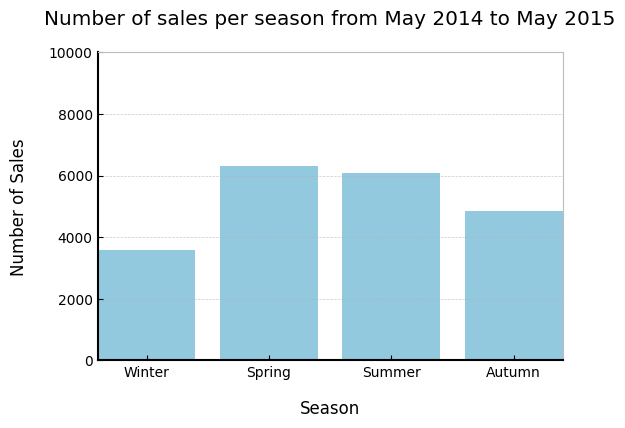

In [ ]:

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# Aggregating data
seasonal_sales = df.groupby('season').size().reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

# Visualization
plt.figure(figsize=(6, 4))
sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, color="skyblue")


plt.title("Number of sales per season from May 2014 to May 2015", pad=20)
plt.xlabel("Season" , labelpad=15)
plt.ylabel("Number of Sales", labelpad=15)

plt.gca().set_facecolor("white") 
plt.gcf().set_facecolor("white")  

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().spines['left'].set_color("black")   
plt.gca().spines['left'].set_linewidth(1.5)   
plt.gca().spines['bottom'].set_color("black") 
plt.gca().spines['bottom'].set_linewidth(1.5) 

plt.ylim(0, 10000)  
plt.xlim(-0.4, 3.4)  

plt.show()

Houses sold in November and December have higher average prices than those in January and February, possibly due to seasonal changes in demand and fewer available houses at the end of the year.

       Average Price  Median Price
month                             
1      528770.615789      440000.0
2      511129.611940      427750.0
3      547059.260583      452000.0
4      563971.422192      479450.0
5      553731.043478      464950.0
6      559759.440210      465000.0
7      548924.124646      470000.0
8      541134.824288      445000.0
9      535385.443662      450000.0
10     539853.307735      449725.0
11     527778.320120      437500.0
12     526766.142354      432500.0


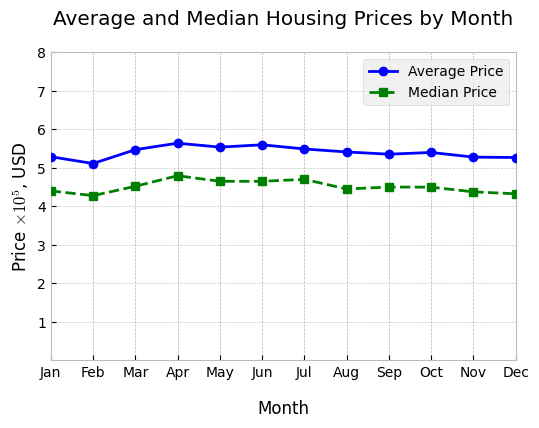

In [ ]:
# 1. Aggregate statistics by month to observe price trends
# We calculate both Mean and Median to account for potential price skewness
monthly_stats = df.groupby('month')['price'].agg(['mean', 'median']).rename(columns={'mean': 'Average Price', 'median': 'Median Price'})

# Displaying the raw statistical table for reference
print(monthly_stats)

# Устанавливаем размер графика
plt.figure(figsize=(6, 4))

# Visualization Setup
plt.gcf().set_facecolor("white")

# Plotting Average Price in Millions (normalized to 10^5 as per your code)
plt.plot(monthly_stats.index, monthly_stats['Average Price']/100000, marker='o', color='b', label='Average Price',zorder=5)

# Plotting Median Price with a dashed line for visual distinction
plt.plot(monthly_stats.index, monthly_stats['Median Price']/100000, marker='s', linestyle='--', color='g', label='Median Price',zorder=5)

# Axis and Legend Configuration
plt.xlim(1, 12)               
plt.ylim(0, 8)      

plt.xlabel("Month",labelpad=15)
plt.ylabel("Price $\\times 10^5$, USD")
plt.title("Average and Median Housing Prices by Month",pad=20)
# Converting month numbers to names for better readability
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Converting month numbers to names for better readability
yticks = plt.yticks()[0]  
yticks = yticks[yticks != 0]  
plt.yticks(yticks)  

plt.legend()
plt.gca().set_facecolor("white")

plt.show()

3. Average house prices are higher in the northern part of the region (by latitude) than in the south, probably due to better access to infrastructure and higher quality of houses in the northern areas.

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_9492/381287257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_9492/381287257.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='price', data=df, palette=colors, order=['North', 'South'])  # Порядок категорий


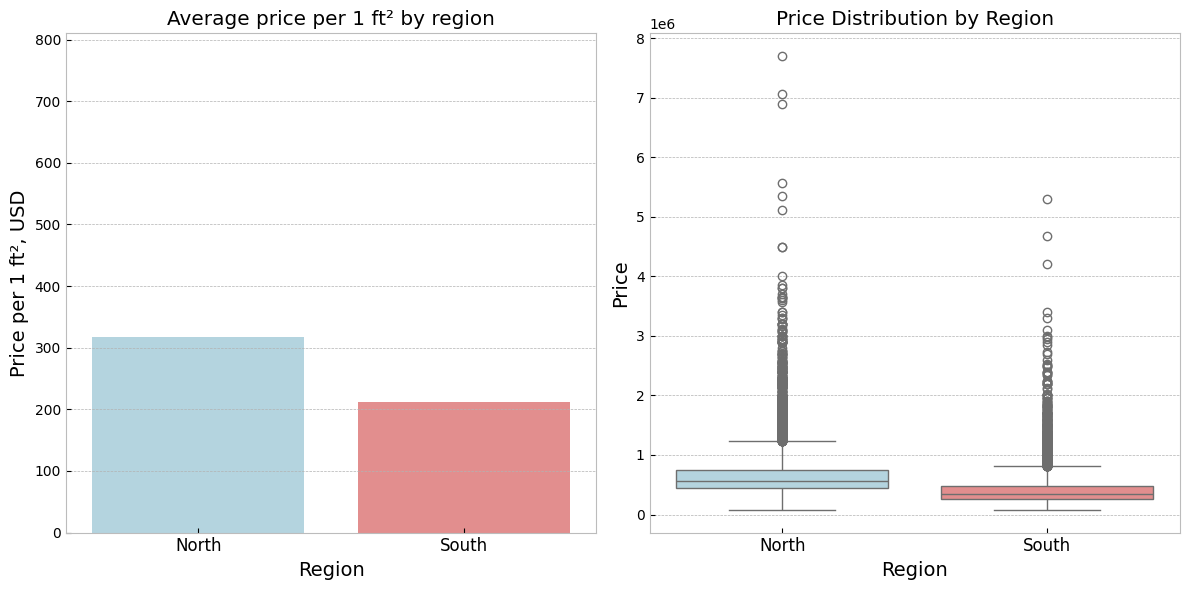

In [ ]:
# Creating a price-per-square-foot metric to normalize for house size
df['price_per_sqft'] = df['price'] / df['sqft_living']

# Binary spatial split based on the median latitude
median_latitude = df['lat'].median()
df['region'] = np.where(df['lat'] > median_latitude, 'North', 'South')

# Aggregating regional price efficiency
region_sqft_means = df.groupby('region')['price_per_sqft'].mean()

# Visualization Setup
colors = {'North': '#ADD8E6', 'South': '#F08080'}


y_min = df['price_per_sqft'].min()
y_max = df['price_per_sqft'].max()

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(
    x=region_sqft_means.index, 
    y=region_sqft_means.values, 
    palette=colors,
    order=['North', 'South'] 
)
plt.ylim(0, y_max)  
plt.title("Average price per 1 ft² by region")
plt.xlabel("Region", fontsize=14)
plt.ylabel("Price per 1 ft², USD", fontsize=14)
plt.xticks(fontsize=12)  
plt.gca().set_facecolor("white") 

# 2. Box Plot 
plt.subplot(1, 2, 2)
sns.boxplot(x='region', y='price', data=df, palette=colors, order=['North', 'South'])  
plt.title("Price Distribution by Region")
plt.xlabel("Region", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.xticks(fontsize=12)  
plt.gca().set_facecolor("white")  

plt.tight_layout()
plt.show()

North

Higher average price per square foot 


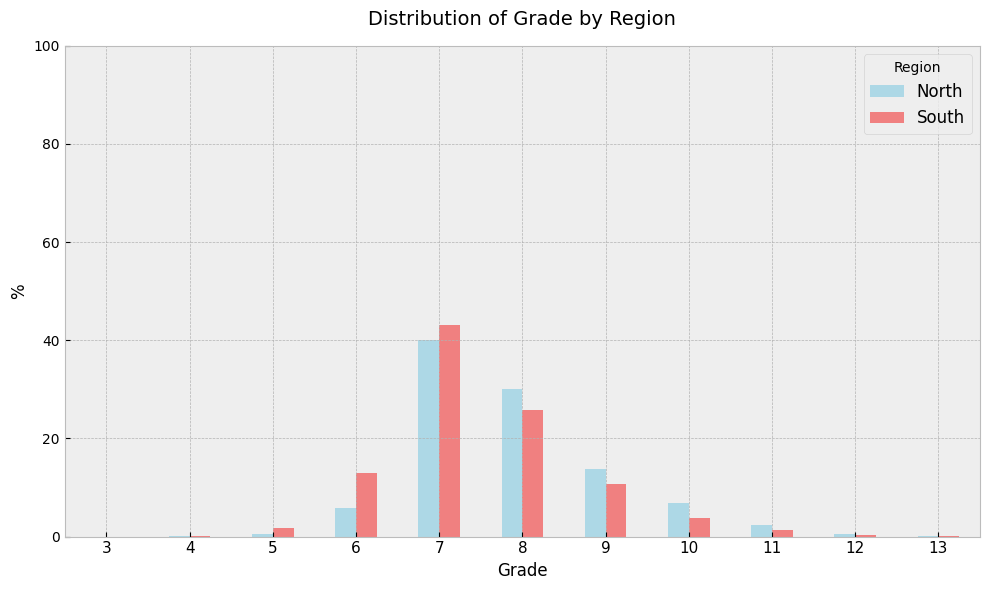

In [ ]:
# 1. Data Preparation: Calculating percentage distribution of grades per region
#  normalize the data (dividing by the sum) to compare the "relative weight" 
# of house quality in North vs South, regardless of the total number of houses.
grade_distribution = df.groupby(['grade', 'region']).size().unstack().fillna(0)
grade_distribution = grade_distribution.div(grade_distribution.sum(axis=0), axis=1) * 100

# 2. Visualization
plt.figure(figsize=(10, 6))

# Plotting the distribution as a bar chart
grade_distribution.plot(kind='bar', color=['lightblue', 'lightcoral'], ax=plt.gca())

# 3. Aesthetics and Labeling
plt.title("Distribution of Grade by Region", fontsize=14, pad=15)
plt.xlabel("Grade", fontsize=12)
plt.ylabel("%", fontsize=12)
plt.legend(title='Region', fontsize=12)

# Ensure x-axis labels (grade numbers) are horizontal for better readability
plt.tick_params(axis='x', rotation=0, labelsize=11)
plt.ylim(0, 100) # Setting scale to 100% for relative comparison

plt.tight_layout()
plt.show()

North

Wider price range with more high-end outliers.
Suitable for premium investments

South

Tighter and more predictable price range.
Offers stability.

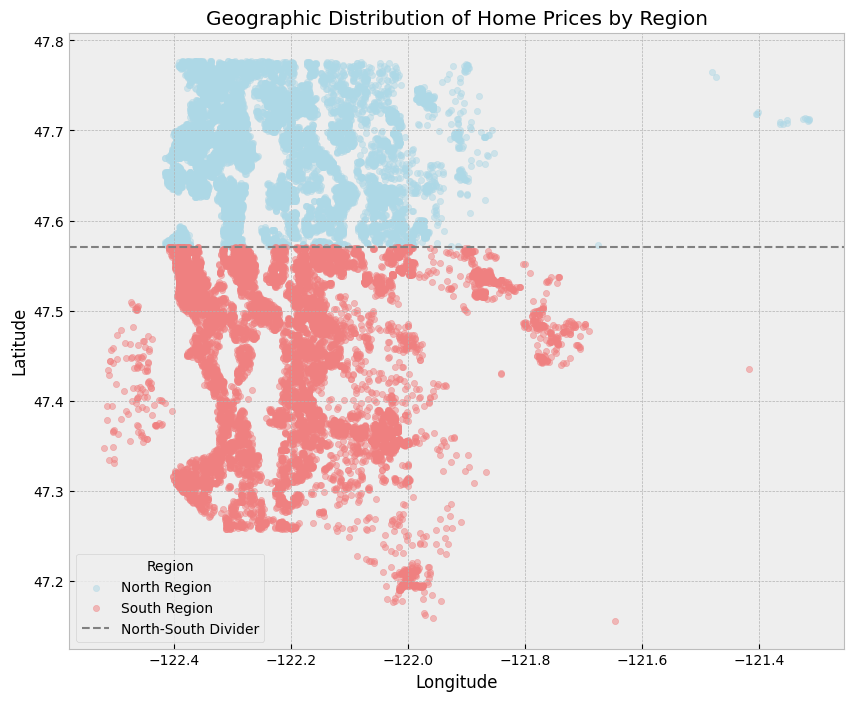

In [38]:
# --- Geospatial Visualization of the North-South Split ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Оп# Define color mapping for regional clarity
colors = {'North': 'lightblue', 'South': 'lightcoral'}

# Scatter plot using Longitude and Latitude to recreate the map of King County
for region, color in colors.items():
    subset = df[df['region'] == region]
    plt.scatter(subset['long'], subset['lat'], 
                color=color, alpha=0.5, s=20, label=f'{region} Region')

# Visualizing the decision boundary (Median Latitude)
median_latitude = df['lat'].median()
plt.axhline(median_latitude, color='gray', linestyle='--', linewidth=1.5, label='North-South Divider')


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Home Prices by Region')
plt.legend(title='Region')

plt.show()
plt.show()

Distribution based on the median latitude: properties located above or below or the median latitude.
Horizontal line - North-South boundary.